#Imports and data loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import copy
from collections import Counter
import os
from glob import glob
from PIL import Image
import random
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import string
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
import math

pd.set_option('display.max_columns', None)  # None means no limit

# Set option to display the full width of each column
pd.set_option('display.width', None)


# full dataset view
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

import plotly.offline as py
from plotly.offline import iplot, init_notebook_mode, plot
import plotly.graph_objs as go
init_notebook_mode(connected = True) # Required to use plotly offline in jupyter notebook

from IPython.display import Markdown
def bold(string):
    display(Markdown(string))

#1. Machine Translation with Optimus Prime


In [ ]:
lines = open("/content/drive/MyDrive/Colab Notebooks/ukr.txt", encoding="utf-8").read().split("\n")
pairs = []
for line in lines:
    parts = line.split("\t")
    if len(parts) < 2:
        continue
    eng = parts[0].strip()
    ukr = parts[1].strip()
    pairs.append((eng, ukr))

print("Pair examples:", pairs[0], pairs[666])
print("Pair amount:", len(pairs))

Pair examples: ('Go.', 'Йди.') ('Answer me.', 'Дайте мені відповідь.')
Pair amount: 160049


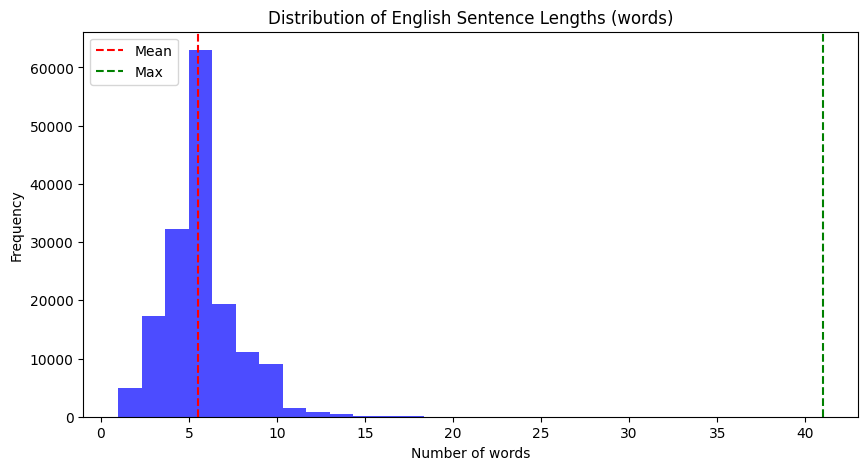

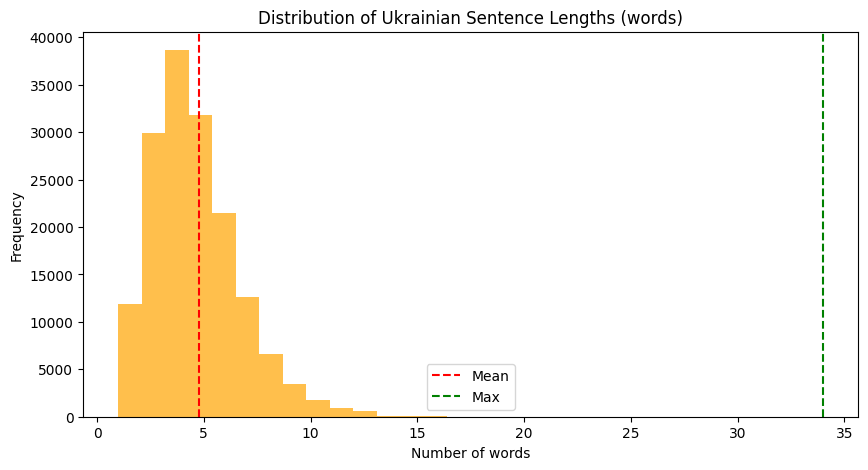

English - max: 41 mean: 5.500896600416122
Ukrainian - max: 34 mean: 4.7931383513798895


In [ ]:
def tokenize(text):
    return text.lower().strip().split()

eng_lengths = [len(tokenize(p[0])) for p in pairs]
ukr_lengths = [len(tokenize(p[1])) for p in pairs]

#eng
plt.figure(figsize=(10,5))
plt.hist(eng_lengths, bins=30, color='blue', alpha=0.7)
plt.title("Distribution of English Sentence Lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.axvline(sum(eng_lengths)/len(eng_lengths), color='red', linestyle='dashed', label='Mean')
plt.axvline(max(eng_lengths), color='green', linestyle='dashed', label='Max')
plt.legend()
plt.show()

#ukr
plt.figure(figsize=(10,5))
plt.hist(ukr_lengths, bins=30, color='orange', alpha=0.7)
plt.title("Distribution of Ukrainian Sentence Lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.axvline(sum(ukr_lengths)/len(ukr_lengths), color='red', linestyle='dashed', label='Mean')
plt.axvline(max(ukr_lengths), color='green', linestyle='dashed', label='Max')
plt.legend()
plt.show()


print("English - max:", max(eng_lengths), "mean:", sum(eng_lengths)/len(eng_lengths))
print("Ukrainian - max:", max(ukr_lengths), "mean:", sum(ukr_lengths)/len(ukr_lengths))

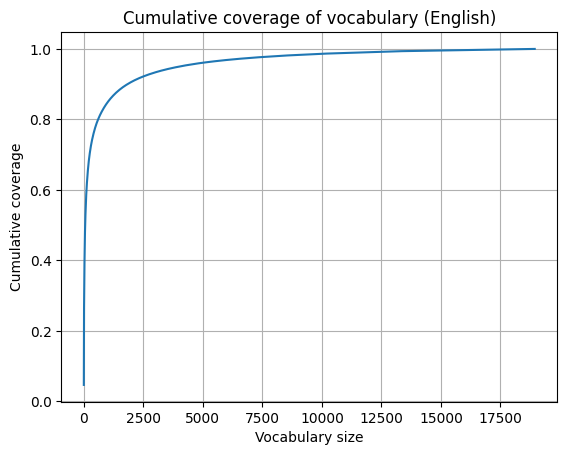

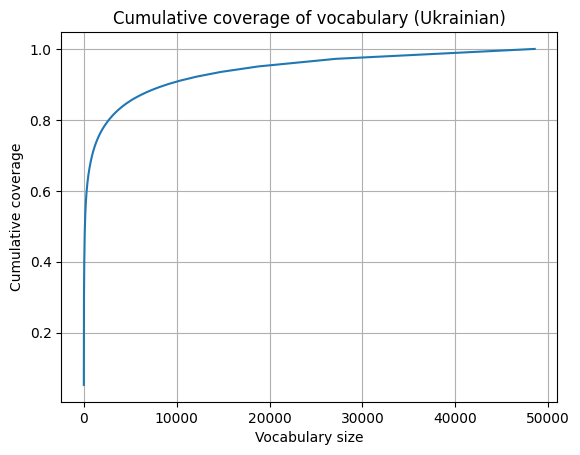

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

eng_sentences = [p[0] for p in pairs]
ukr_sentences = [p[1] for p in pairs]

all_eng_tokens = [t for s in eng_sentences for t in tokenize(s)]
all_ukr_tokens = [t for s in ukr_sentences for t in tokenize(s)]

eng_counter = Counter(all_eng_tokens)
ukr_counter = Counter(all_ukr_tokens)

def plot_cumulative(counter, lang):
    freqs = [count for word, count in counter.most_common()]
    cumsum = [sum(freqs[:i+1])/sum(freqs) for i in range(len(freqs))]
    plt.plot(range(len(freqs)), cumsum)
    plt.title(f"Cumulative coverage of vocabulary ({lang})")
    plt.xlabel("Vocabulary size")
    plt.ylabel("Cumulative coverage")
    plt.grid(True)
    plt.show()

plot_cumulative(eng_counter, "English")
plot_cumulative(ukr_counter, "Ukrainian")

In [ ]:
#optimal vocabulary size is 18000, because ENG is 18k max

#max len will be 35

In [ ]:
MAX_VOCAB = 18000
specials = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]

def build_vocab(sentences):
    counter = Counter()
    for s in sentences:
        counter.update(tokenize(s))
    most_common = counter.most_common(MAX_VOCAB - len(specials))
    itos = specials + [w for w, _ in most_common]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos

eng_sentences = [p[0] for p in pairs]
ukr_sentences = [p[1] for p in pairs]

eng_stoi, eng_itos = build_vocab(eng_sentences)
ukr_stoi, ukr_itos = build_vocab(ukr_sentences)

PAD_IDX = eng_stoi["[PAD]"]
UNK_IDX = eng_stoi["[UNK]"]
BOS_IDX = eng_stoi["[BOS]"]
EOS_IDX = eng_stoi["[EOS]"]

print("ENG vocab size:", len(eng_stoi))
print("UKR vocab size:", len(ukr_stoi))

MAX_LEN_SRC = 35
MAX_LEN_TGT = 35


ENG vocab size: 18000
UKR vocab size: 18000


In [ ]:
def text_to_indices(text, vocab_dict, add_bos_eos=False):
    tokens = tokenize(text)
    indices = []

    if add_bos_eos:
        indices.append(BOS_IDX)

    for token in tokens:
        indices.append(vocab_dict.get(token, UNK_IDX))

    if add_bos_eos:
        indices.append(EOS_IDX)

    return indices

def process_sentence_pair(src_sentence, tgt_sentence):
    src_ids = text_to_indices(src_sentence, eng_stoi, add_bos_eos=False)
    tgt_full = text_to_indices(tgt_sentence, ukr_stoi, add_bos_eos=True)
    tgt_input = tgt_full[:-1]
    tgt_output = tgt_full[1:]

    src_ids = src_ids[:MAX_LEN_SRC] + [PAD_IDX] * (MAX_LEN_SRC - len(src_ids))
    tgt_input = tgt_input[:MAX_LEN_TGT] + [PAD_IDX] * (MAX_LEN_TGT - len(tgt_input))
    tgt_output = tgt_output[:MAX_LEN_TGT] + [PAD_IDX] * (MAX_LEN_TGT - len(tgt_output))

    return src_ids, tgt_input, tgt_output

In [ ]:
BATCH_SIZE = 64

class UkrTranslationDataset(Dataset):
    def __init__(self, sentence_pairs):
        self.data = sentence_pairs

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_sentence, tgt_sentence = self.data[idx]
        src_ids, tgt_input, tgt_output = process_sentence_pair(src_sentence, tgt_sentence)
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_input, dtype=torch.long),
            torch.tensor(tgt_output, dtype=torch.long)
        )


random.shuffle(pairs)
split_point = int(0.8 * len(pairs))
train_data = pairs[:split_point]
val_data = pairs[split_point:]

train_dataset = UkrTranslationDataset(train_data)
val_dataset = UkrTranslationDataset(val_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 128039
Validation size: 32010


In [ ]:
def create_pad_mask(batch, pad_index=PAD_IDX):
    return (batch == pad_index)

def make_causal_mask(seq_len, device):
    return torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device), diagonal=1)

class TokenPositionEmbed(nn.Module):
    def __init__(self, vocab_size, model_dim, max_len=50, dropout_rate=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, model_dim, padding_idx=PAD_IDX)
        self.pos_embedding = nn.Embedding(max_len, model_dim)
        self.dropout_layer = nn.Dropout(dropout_rate)

    def forward(self, x):
        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        return self.dropout_layer(self.token_embedding(x) + self.pos_embedding(positions))

In [ ]:
class OptimusPrime(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, model_dim=128, n_heads=8, n_layers=4, ff_dim=512,
                 max_src_len=MAX_LEN_SRC, max_tgt_len=MAX_LEN_TGT, dropout=0.1):
        super().__init__()
        self.src_embed = TokenPositionEmbed(src_vocab_size, model_dim, max_src_len, dropout)
        self.tgt_embed = TokenPositionEmbed(tgt_vocab_size, model_dim, max_tgt_len, dropout)

        enc_layer = nn.TransformerEncoderLayer(d_model=model_dim, nhead=n_heads, dim_feedforward=ff_dim,
                                               dropout=dropout, batch_first=True)
        dec_layer = nn.TransformerDecoderLayer(d_model=model_dim, nhead=n_heads, dim_feedforward=ff_dim,
                                               dropout=dropout, batch_first=True)

        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_layers)
        self.output_layer = nn.Linear(model_dim, tgt_vocab_size)

    def forward(self, src_seq, tgt_seq):
        src_mask = create_pad_mask(src_seq)
        tgt_mask = create_pad_mask(tgt_seq)
        src_emb = self.src_embed(src_seq)
        tgt_emb = self.tgt_embed(tgt_seq)
        memory = self.encoder(src_emb, src_key_padding_mask=src_mask)
        seq_len = tgt_seq.size(1)
        causal_mask = make_causal_mask(seq_len, device=tgt_seq.device)
        dec_out = self.decoder(tgt_emb, memory, tgt_mask=causal_mask,
                               tgt_key_padding_mask=tgt_mask, memory_key_padding_mask=src_mask)
        return self.output_layer(dec_out)

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = OptimusPrime(len(eng_stoi), len(ukr_stoi)).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optim = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, total_tokens = 0, 0
    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt_in)
        B, T, V = logits.shape
        loss = loss_fn(logits.view(B*T, V), tgt_out.view(B*T))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * (tgt_out != PAD_IDX).sum().item()
        total_tokens += (tgt_out != PAD_IDX).sum().item()
    return total_loss / total_tokens

@torch.no_grad()
def evaluate_model(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_tokens = 0, 0
    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
        logits = model(src, tgt_in)
        B, T, V = logits.shape
        loss = loss_fn(logits.view(B*T, V), tgt_out.view(B*T))
        total_loss += loss.item() * (tgt_out != PAD_IDX).sum().item()
        total_tokens += (tgt_out != PAD_IDX).sum().item()
    return total_loss / total_tokens

In [ ]:
EPOCHS = 20
for epoch in range(1, EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader, optim, loss_fn, DEVICE)
    val_loss = evaluate_model(model, val_loader, loss_fn, DEVICE)
    print(f"Epoch {epoch}/{EPOCHS} - train loss: {train_loss:.4f}, val loss: {val_loss:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning:

The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)



Epoch 1/20 - train loss: 3.8468, val loss: 2.6437
Epoch 2/20 - train loss: 2.2936, val loss: 1.9325
Epoch 3/20 - train loss: 1.7184, val loss: 1.6539
Epoch 4/20 - train loss: 1.4334, val loss: 1.5212
Epoch 5/20 - train loss: 1.2655, val loss: 1.4372
Epoch 6/20 - train loss: 1.1502, val loss: 1.3967
Epoch 7/20 - train loss: 1.0654, val loss: 1.3722
Epoch 8/20 - train loss: 1.0004, val loss: 1.3462
Epoch 9/20 - train loss: 0.9455, val loss: 1.3306
Epoch 10/20 - train loss: 0.9012, val loss: 1.3189
Epoch 11/20 - train loss: 0.8627, val loss: 1.3035
Epoch 12/20 - train loss: 0.8303, val loss: 1.3033
Epoch 13/20 - train loss: 0.8015, val loss: 1.2961
Epoch 14/20 - train loss: 0.7748, val loss: 1.2814
Epoch 15/20 - train loss: 0.7504, val loss: 1.2834
Epoch 16/20 - train loss: 0.7295, val loss: 1.2827
Epoch 17/20 - train loss: 0.7121, val loss: 1.2720
Epoch 18/20 - train loss: 0.6922, val loss: 1.2695
Epoch 19/20 - train loss: 0.6744, val loss: 1.2723
Epoch 20/20 - train loss: 0.6611, val lo

In [ ]:
@torch.no_grad()
def translate_sentence(model, sentence, max_len=MAX_LEN_TGT):
    model.eval()
    device = next(model.parameters()).device

    src_ids = encode(sentence, eng_stoi, add_specials=False)
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    src_mask = create_pad_mask(src_tensor)
    memory = model.encoder(model.src_emb(src_tensor), src_key_padding_mask=src_mask)

    tgt_ids = [BOS_IDX]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_ids, dtype=torch.long, device=device).unsqueeze(0)
        tgt_mask = make_causal_mask(tgt_tensor.size(1), device=device)
        dec_out = model.decoder(model.tgt_emb(tgt_tensor), memory,
                                tgt_mask=tgt_mask,
                                tgt_key_padding_mask=create_pad_mask(tgt_tensor),
                                memory_key_padding_mask=src_mask)
        logits = model.output_proj(dec_out[:, -1, :])
        next_id = logits.argmax(dim=-1).item()
        tgt_ids.append(next_id)
        if next_id == EOS_IDX:
            break

    tokens = [ukr_itos[i] for i in tgt_ids if i not in (PAD_IDX, BOS_IDX, EOS_IDX)]
    return " ".join(tokens)


In [ ]:
examples = [
    "Hello!",
    "How are you?",
    "I am looking for a new apartment.",
    "She didn't come because she was sick.",
    "I really like this girl, I do not want to die",
]

for sent in examples:
    print("EN:", sent)
    print("UKR:", translate_sentence(model, sent))
    print()

EN: Hello!
UKR: вітаю!

EN: How are you?
UKR: як твої справи?

EN: I am looking for a new apartment.
UKR: я шукаю нову квартиру.

EN: She didn't come because she was sick.
UKR: вона не прийшов через роботу, бо хвора.

EN: I really like this girl, but I do not want to die
UKR: мені дуже подобається ця дівчина, але я не хочу помирати.



In [ ]:
#it works, some missings are present due to poor vocabulary choice and limitations

# 2. Image Generation (VAE + Conv)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import torch.optim as optim

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_ds = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)


In [3]:
print("Total samples:", len(train_ds))
print("Image tensor shape:", train_ds[0][0].shape)

Total samples: 60000
Image tensor shape: torch.Size([1, 28, 28])


In [4]:
print("Classes from dataset:")
for i, name in enumerate(train_ds.classes):
    print(f"{i}: {name}")

Classes from dataset:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


In [5]:
labels = [label for _, label in train_ds]
counts = Counter(labels)
print("\nSamples per class:")
for i, name in enumerate(train_ds.classes):
    print(f"{i} ({name}): {counts[i]}")


Samples per class:
0 (T-shirt/top): 6000
1 (Trouser): 6000
2 (Pullover): 6000
3 (Dress): 6000
4 (Coat): 6000
5 (Sandal): 6000
6 (Shirt): 6000
7 (Sneaker): 6000
8 (Bag): 6000
9 (Ankle boot): 6000


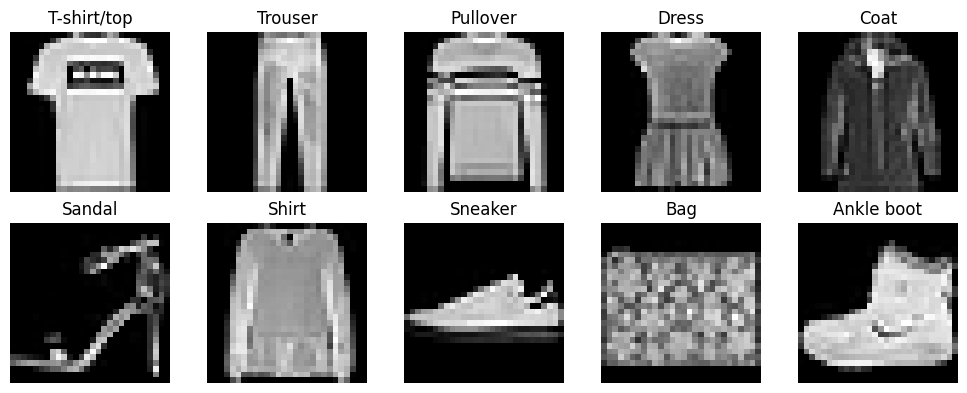

In [6]:
#image per class
fig = plt.figure(figsize=(10, 4))

for cls_idx, cls_name in enumerate(train_ds.classes):
    for img, label in train_ds:
        if label == cls_idx:
            ax = fig.add_subplot(2, 5, cls_idx + 1)
            ax.imshow(img.squeeze(), cmap="gray")
            ax.set_title(cls_name)
            ax.axis("off")
            break

plt.tight_layout()
plt.show()

In [37]:
BATCH_SIZE = 128
Z_DIM = 32
BETA = 0.3
EPOCHS = 40

class ConvVAE(nn.Module):
    def __init__(self, z_dim=32):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 14 -> 7
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, z_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, z_dim)

        # Decoder
        self.fc_dec = nn.Linear(z_dim, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),   # 14 -> 28
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        z = self.reparameterize(mu, logvar)

        h_dec = self.fc_dec(z).view(-1, 64, 7, 7)
        x_hat = self.decoder(h_dec)

        return x_hat, mu, logvar

def vae_loss(x_hat, x, mu, logvar):
    recon = nn.functional.binary_cross_entropy(x_hat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + BETA * kl


In [39]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvVAE(Z_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.to(DEVICE)

        x_hat, mu, logvar = model(x)
        loss = vae_loss(x_hat, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, loss: {total_loss / len(train_loader.dataset):.4f}")


Epoch 1/40, loss: 267.4653
Epoch 2/40, loss: 236.2520
Epoch 3/40, loss: 231.7281
Epoch 4/40, loss: 229.6262
Epoch 5/40, loss: 228.2745
Epoch 6/40, loss: 227.3070
Epoch 7/40, loss: 226.5947
Epoch 8/40, loss: 226.0099
Epoch 9/40, loss: 225.5584
Epoch 10/40, loss: 225.2008
Epoch 11/40, loss: 224.8646
Epoch 12/40, loss: 224.6271
Epoch 13/40, loss: 224.3665
Epoch 14/40, loss: 224.1658
Epoch 15/40, loss: 223.9566
Epoch 16/40, loss: 223.7934
Epoch 17/40, loss: 223.6698
Epoch 18/40, loss: 223.4818
Epoch 19/40, loss: 223.3881
Epoch 20/40, loss: 223.2543
Epoch 21/40, loss: 223.1129
Epoch 22/40, loss: 223.0337
Epoch 23/40, loss: 222.9429
Epoch 24/40, loss: 222.8343
Epoch 25/40, loss: 222.7575
Epoch 26/40, loss: 222.6886
Epoch 27/40, loss: 222.5919
Epoch 28/40, loss: 222.5206
Epoch 29/40, loss: 222.4703
Epoch 30/40, loss: 222.3864
Epoch 31/40, loss: 222.3186
Epoch 32/40, loss: 222.2754
Epoch 33/40, loss: 222.2169
Epoch 34/40, loss: 222.1658
Epoch 35/40, loss: 222.1014
Epoch 36/40, loss: 222.0648
E

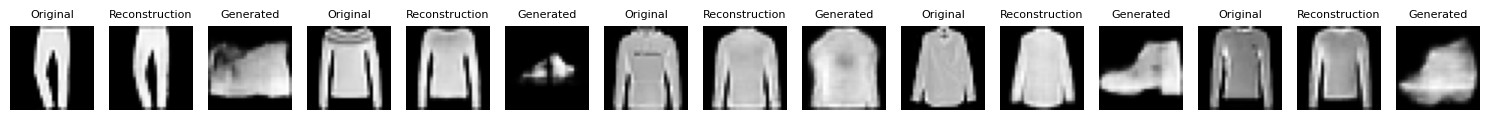

In [40]:
def show_conv_vae_row(model, loader, n_examples=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(DEVICE)[:n_examples]

    with torch.no_grad():
        x_hat, _, _ = model(x)

        z_random = torch.randn(n_examples, Z_DIM, device=DEVICE)
        h_dec = model.fc_dec(z_random).view(-1, 64, 7, 7)
        x_gen = model.decoder(h_dec)

    fig, axes = plt.subplots(1, n_examples*3, figsize=(n_examples*3, 3))

    for i in range(n_examples):
        axes[i*3].imshow(x[i].cpu().squeeze(), cmap='gray')
        axes[i*3].axis('off')
        axes[i*3].set_title("Original", fontsize=8)

        axes[i*3+1].imshow(x_hat[i].cpu().squeeze(), cmap='gray')
        axes[i*3+1].axis('off')
        axes[i*3+1].set_title("Reconstruction", fontsize=8)

        axes[i*3+2].imshow(x_gen[i].cpu().squeeze(), cmap='gray')
        axes[i*3+2].axis('off')
        axes[i*3+2].set_title("Generated", fontsize=8)

    plt.tight_layout()
    plt.show()

show_conv_vae_row(model, train_loader, n_examples=5)


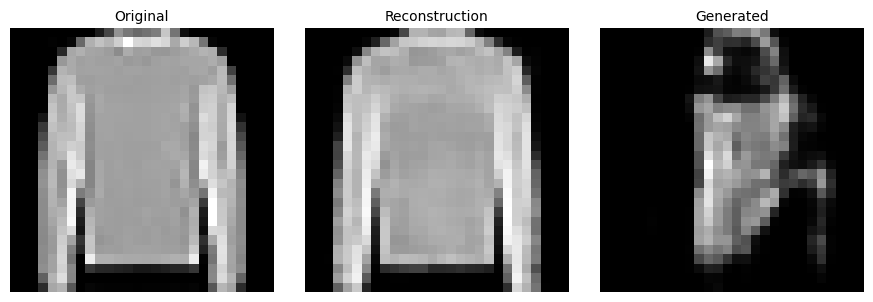

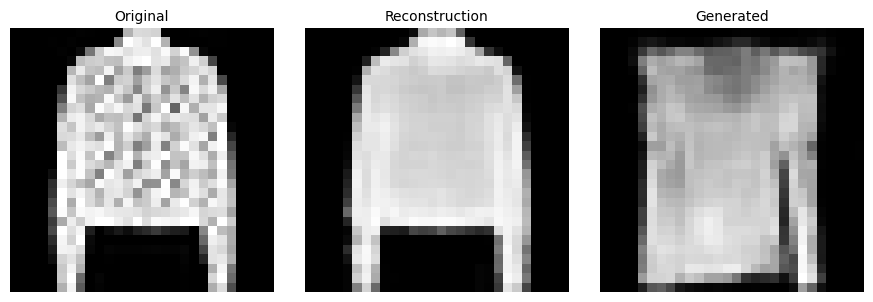

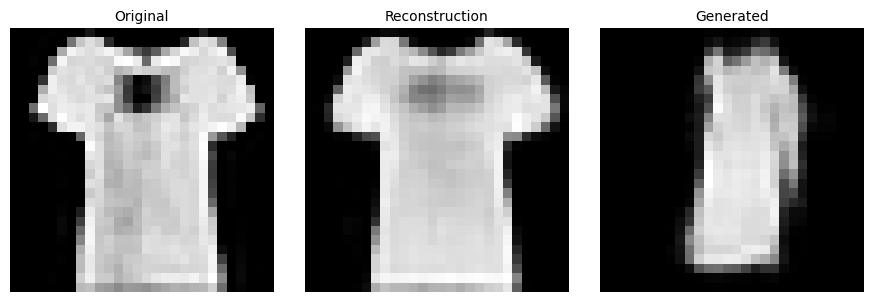

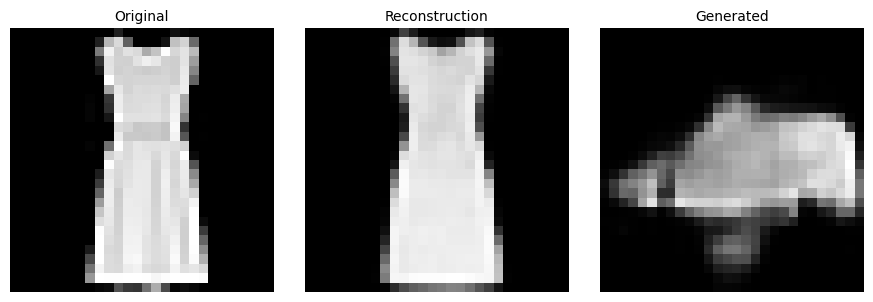

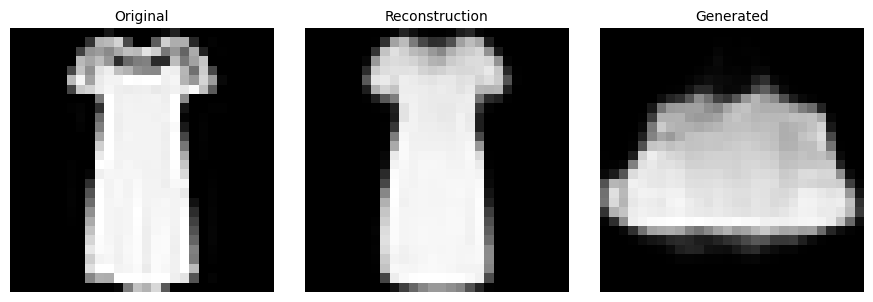

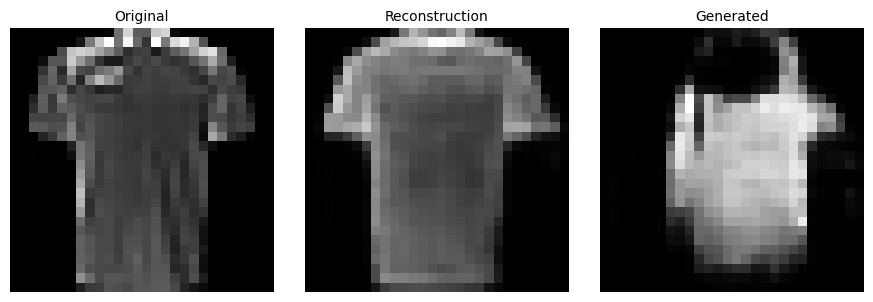

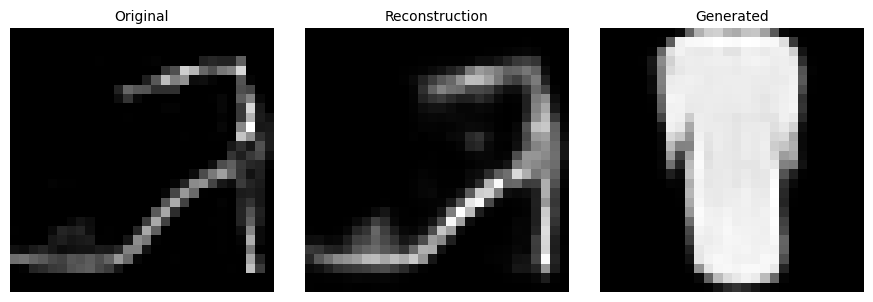

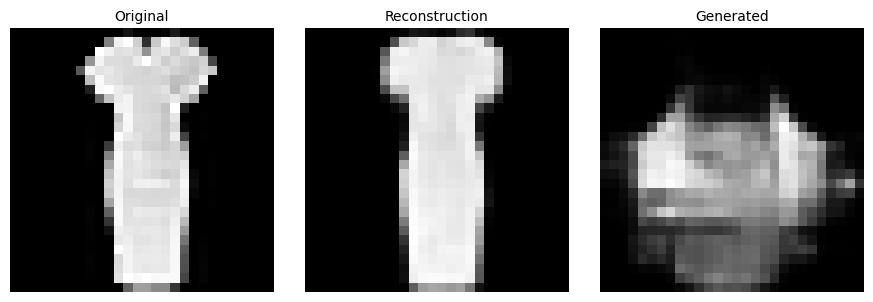

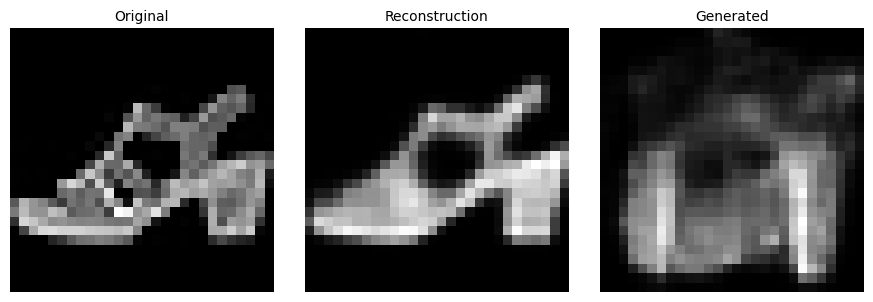

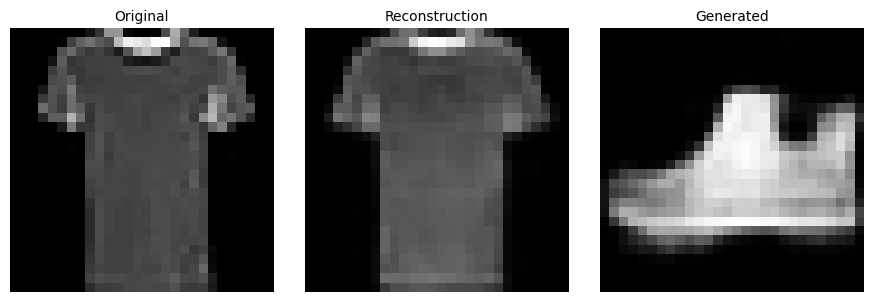

In [41]:
def show_conv_vae_column(model, loader, n_examples=8):

    model.eval()
    x, _ = next(iter(loader))
    x = x.to(DEVICE)[:n_examples]

    with torch.no_grad():
        x_hat, _, _ = model(x)

        z_random = torch.randn(n_examples, Z_DIM, device=DEVICE)
        h_dec = model.fc_dec(z_random).view(-1, 64, 7, 7)
        x_gen = model.decoder(h_dec)

    for i in range(n_examples):
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))

        axes[0].imshow(x[i].cpu().squeeze(), cmap='gray')
        axes[0].axis('off')
        axes[0].set_title("Original", fontsize=10)

        axes[1].imshow(x_hat[i].cpu().squeeze(), cmap='gray')
        axes[1].axis('off')
        axes[1].set_title("Reconstruction", fontsize=10)

        axes[2].imshow(x_gen[i].cpu().squeeze(), cmap='gray')
        axes[2].axis('off')
        axes[2].set_title("Generated", fontsize=10)

        plt.tight_layout()
        plt.show()

show_conv_vae_column(model, train_loader, n_examples=10)


# From tutorial, copy-pasted code (just for fun, skip this pls)  

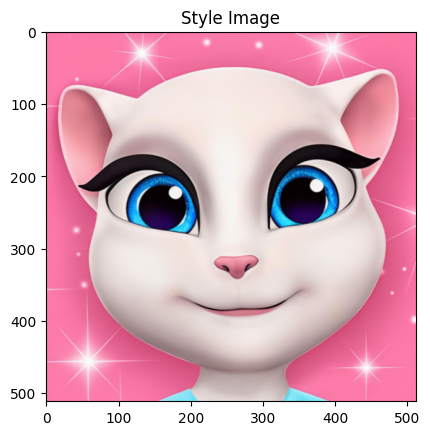

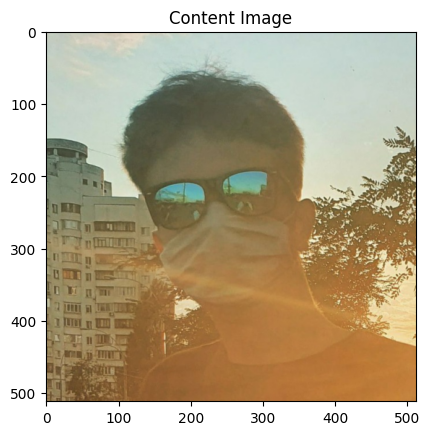

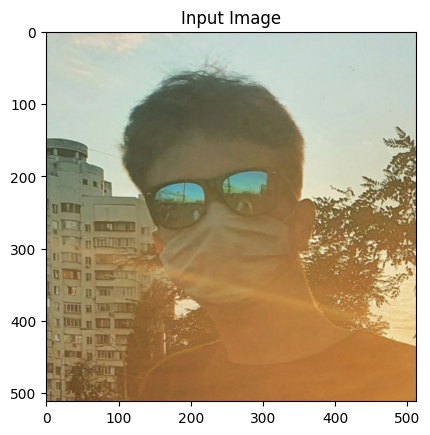

Building the style transfer model..
Optimizing..


/usr/local/lib/python3.12/dist-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


run [50]:
Style Loss : 391.876556 Content Loss: 10.813030

run [100]:
Style Loss : 79.952995 Content Loss: 12.913146

run [150]:
Style Loss : 38.195396 Content Loss: 13.053612

run [200]:
Style Loss : 23.121519 Content Loss: 13.107814

run [250]:
Style Loss : 13.068523 Content Loss: 13.566854

run [300]:
Style Loss : 8.038908 Content Loss: 12.989475



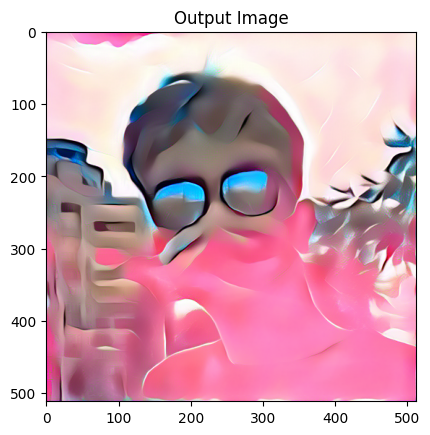

In [47]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# desired size of the output image
imsize = 512 if torch.cuda.is_available() else 128  # use small size if no GPU

loader = transforms.Compose([
    transforms.Resize(imsize),  # scale imported image
    transforms.ToTensor()])  # transform it into a torch tensor


def image_loader(image_name):
    image = Image.open(image_name)
    # fake batch dimension required to fit network's input dimensions
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)


style_img = image_loader("/content/drive/MyDrive/Colab Notebooks/agela_v.jpg")
content_img = image_loader("/content/drive/MyDrive/Colab Notebooks/2025-12-18 21.08.13.jpg")

assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"

unloader = transforms.ToPILImage()  # reconvert into PIL image

plt.ion()

def imshow(tensor, title=None):
    image = tensor.cpu().clone()  # we clone the tensor to not do changes on it
    image = image.squeeze(0)      # remove the fake batch dimension
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # pause a bit so that plots are updated


plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')



class ContentLoss(nn.Module):

    def __init__(self, target,):
        super(ContentLoss, self).__init__()
        # we 'detach' the target content from the tree used
        # to dynamically compute the gradient: this is a stated value,
        # not a variable. Otherwise the forward method of the criterion
        # will throw an error.
        self.target = target.detach()

    def forward(self, input):
        self.loss = F.mse_loss(input, self.target)
        return input





def gram_matrix(input):
  a, b, c, d = input.size()  # a=batch size(=1)
  # b=number of feature maps
  # (c,d)=dimensions of a f. map (N=c*d)

  features = input.view(a * b, c * d)  # resize F_XL into \hat F_XL

  G = torch.mm(features, features.t())  # compute the gram product

  # we 'normalize' the values of the gram matrix
  # by dividing by the number of element in each feature maps.
  return G.div(a * b * c * d)



class StyleLoss(nn.Module):

    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = F.mse_loss(G, self.target)
        return input
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()

cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225])

# create a module to normalize input image so we can easily put it in a
# ``nn.Sequential``
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # .view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        # normalize ``img``
        return (img - self.mean) / self.std

# desired depth layers to compute style/content losses :
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_img, content_img,
                               content_layers=content_layers_default,
                               style_layers=style_layers_default):
    # normalization module
    normalization = Normalization(normalization_mean, normalization_std)

    # just in order to have an iterable access to or list of content/style
    # losses
    content_losses = []
    style_losses = []

    # assuming that ``cnn`` is a ``nn.Sequential``, so we make a new ``nn.Sequential``
    # to put in modules that are supposed to be activated sequentially
    model = nn.Sequential(normalization)

    i = 0  # increment every time we see a conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = 'conv_{}'.format(i)
        elif isinstance(layer, nn.ReLU):
            name = 'relu_{}'.format(i)
            # The in-place version doesn't play very nicely with the ``ContentLoss``
            # and ``StyleLoss`` we insert below. So we replace with out-of-place
            # ones here.
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = 'pool_{}'.format(i)
        elif isinstance(layer, nn.BatchNorm2d):
            name = 'bn_{}'.format(i)
        else:
            raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module("content_loss_{}".format(i), content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # add style loss:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module("style_loss_{}".format(i), style_loss)
            style_losses.append(style_loss)

    # now we trim off the layers after the last content and style losses
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[:(i + 1)]

    return model, style_losses, content_losses



input_img = content_img.clone()
# if you want to use white noise by using the following code:
#
# .. code-block:: python
#
#    input_img = torch.randn(content_img.data.size())

# add the original input image to the figure:
plt.figure()
imshow(input_img, title='Input Image')


def get_input_optimizer(input_img):
    # this line to show that input is a parameter that requires a gradient
    optimizer = optim.LBFGS([input_img])
    return optimizer


def run_style_transfer(cnn, normalization_mean, normalization_std,
                       content_img, style_img, input_img, num_steps=300,
                       style_weight=1000000, content_weight=1):
    """Run the style transfer."""
    print('Building the style transfer model..')
    model, style_losses, content_losses = get_style_model_and_losses(cnn,
        normalization_mean, normalization_std, style_img, content_img)

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    # We also put the model in evaluation mode, so that specific layers
    # such as dropout or batch normalization layers behave correctly.
    model.eval()
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')
    run = [0]
    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print('Style Loss : {:4f} Content Loss: {:4f}'.format(
                    style_score.item(), content_score.item()))
                print()

            return style_score + content_score

        optimizer.step(closure)

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img




output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img)

plt.figure()
imshow(output, title='Output Image')

# sphinx_gallery_thumbnail_number = 4
plt.ioff()
plt.show()


# 3. Hugging Face (b and c)


b)

zero-shot-classification

In [12]:
from transformers import pipeline

# zero-shot classification pipeline
classifier = pipeline("zero-shot-classification",
                      model="joeddav/xlm-roberta-large-xnli")

text = "Цей фільм надзвичайно зворушливий і мені дуже сподобався"
labels = ["positive emotion", "negative emotion", "neutral"]
result = classifier(text, candidate_labels=labels)
print(result)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


{'sequence': 'Цей фільм надзвичайно зворушливий і мені дуже сподобався', 'labels': ['positive emotion', 'neutral', 'negative emotion'], 'scores': [0.9884148240089417, 0.006102259736508131, 0.005482994485646486]}


In [36]:
text = "Сьогодні я доробив останню лабораторну роботу в семестрі"
labels = ["позитив", "негатив", "нейтральне"]
result = classifier(text, candidate_labels=labels)
print(result['sequence'])
print(result['labels'])
print(result['scores'])

Сьогодні я доробив останню лабораторну роботу в семестрі
['позитив', 'негатив', 'нейтральне']
[0.3585853576660156, 0.3415658473968506, 0.2998487949371338]


In [37]:
text = "Більше немає робіт і можна відпочивати"
labels = ["позитив", "негатив", "нейтральне"]
result = classifier(text, candidate_labels=labels)
print(result['sequence'])
print(result['labels'])
print(result['scores'])

Більше немає робіт і можна відпочивати
['позитив', 'нейтральне', 'негатив']
[0.7572307586669922, 0.21947894990444183, 0.023290252313017845]


In [39]:
text = "Я навчився штучному інтеллекту, який допоможе мені в роботі"
labels = ["позитив", "негатив", "нейтральне"]
result = classifier(text, candidate_labels=labels)
print(result['sequence'])
print(result['labels'])
print(result['scores'])

Я навчився штучному інтеллекту, який допоможе мені в роботі
['позитив', 'нейтральне', 'негатив']
[0.9772275686264038, 0.013853837735950947, 0.008918576873838902]


In [48]:
text = "DDOS атаки ростуть"
labels = ["безпека", "програмування"]
result = classifier(text, candidate_labels=labels)
print(result['sequence'])
print(result['labels'])
print(result['scores'])

DDOS атаки ростуть
['безпека', 'програмування']
[0.8583886027336121, 0.14161139726638794]


In [50]:
texts = [
    "Цей фільм надзвичайно зворушливий і мені дуже сподобався",
    "Я розчарований якістю обслуговування в ресторані",
    "Сьогодні чудова погода для прогулянки на вулиці",
    "Моя команда виграла змагання, я щасливий",
    "Я не можу знайти свій телефон і це дратує",
    "В університеті пройшла цікава лекція з кібербезпеки",
    "Новий смартфон має потужну камеру та швидкий процесор",
    "Сьогодні в місті відкрили виставку сучасного мистецтва",
    "Ми плануємо піти на футбол цього вечора",
    "Програма для вивчення мов допомагає мені щодня",
    "Завтра очікується сильний дощ та вітер",
    "Я щасливий, що мій улюблений письменник видав нову книгу",
    "Моя команда провела тренування перед змаганнями",
    "Вчора я грав у шахи з другом, це було весело",
    "Розробники випустили оновлення для безпеки програмного забезпечення"
]

labels = [
    "позитив",
    "негатив",
    "нейтрально",
    "погода",
    "спорт",
    "технології",
    "культура",
    "освіта"
]

for text in texts:
    result = classifier(text, candidate_labels=labels)
    print(f"Текст: {text}")
    print(f"Передбачувані мітки: {result['labels']}")
    print(f"Ймовірності: {result['scores']}")
    print("-"*60)

Текст: Цей фільм надзвичайно зворушливий і мені дуже сподобався
Передбачувані мітки: ['позитив', 'культура', 'спорт', 'освіта', 'нейтрально', 'негатив', 'технології', 'погода']
Ймовірності: [0.9831898808479309, 0.005197735037654638, 0.0026744152419269085, 0.002173089189454913, 0.0019100173376500607, 0.0018688130658119917, 0.0017765082884579897, 0.0012095451820641756]
------------------------------------------------------------
Текст: Я розчарований якістю обслуговування в ресторані
Передбачувані мітки: ['негатив', 'технології', 'нейтрально', 'культура', 'освіта', 'спорт', 'позитив', 'погода']
Ймовірності: [0.9315825700759888, 0.017291497439146042, 0.014409991912543774, 0.013808706775307655, 0.008160756900906563, 0.007795997895300388, 0.004395197611302137, 0.0025552234146744013]
------------------------------------------------------------
Текст: Сьогодні чудова погода для прогулянки на вулиці
Передбачувані мітки: ['погода', 'позитив', 'нейтрально', 'спорт', 'освіта', 'технології', 'куль

summarisation

In [64]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch

model_name = "SGaleshchuk/t5-large-ua-news"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")

In [65]:
summarizer = pipeline(
    "summarization",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

text_uk = """
Український уряд оголосив про запуск нової програми підтримки малого бізнесу,
яка передбачає субсидії та податкові пільги для підприємців у регіонах.
Міністерство економіки зазначило, що програма спрямована на стимулювання
локального виробництва та створення нових робочих місць. Підприємці вже
висловили зацікавленість у цій ініціативі, адже це дасть змогу розширити
свій бізнес та інвестувати в нові технології. Очікується, що програма
запрацює з наступного кварталу.
"""

summary = summarizer(
    text_uk,
    max_length=50,
    min_length=20,
    do_sample=False
)


print(summary[0]["summary_text"])

Device set to use cuda:0


Міністерство розвитку економіки, торгівлі та сільського господарства України оголосило про запуск нової програми підтримки малого бізнесу. 


In [68]:
text_uk_3 = """
Українська компанія розробила новий мобільний додаток для автоматизації обліку
витрат та доходів користувачів. Додаток використовує алгоритми машинного
навчання для аналізу фінансових потоків та надання порад щодо оптимізації
бюджету. Програма вже доступна для Android та iOS, і її завантажили понад
50 тисяч користувачів за перший місяць після релізу. Команда планує додати
функції інтеграції з банківськими картками та криптогаманцями.
"""

summary = summarizer(
    text_uk_3,
    max_length=35,
    min_length=20,
    do_sample=False
)


print(summary[0]["summary_text"])


Український мобільний додаток для автоматизації обліку витрат та доходів користувачів уже завантажили понад 50 тисяч користувач


translation

In [61]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
import torch

model_name = "facebook/mbart-large-50-many-to-many-mmt"
tokenizer = MBart50TokenizerFast.from_pretrained(model_name)
model = MBartForConditionalGeneration.from_pretrained(model_name)

text_uk = "Вчора пройшла конференція з кібербезпеки, де обговорювали нові методи захисту інформації в системах. Також було приділено увагу питанням фішингу та тренінгів для співробітників."


def translate(text, target_lang):
    tokenizer.src_lang = "uk_UA"
    encoded = tokenizer(text, return_tensors="pt")
    generated_tokens = model.generate(**encoded, forced_bos_token_id=tokenizer.lang_code_to_id[target_lang])
    return tokenizer.decode(generated_tokens[0], skip_special_tokens=True)

translation = translate(text_uk, 'en_XX')
print(translation)

Yesterday, there was a cybersecurity conference where they talked about new ways to protect information in systems, and they also talked about banking and employee training.


c)Text-to-Image

In [70]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [76]:
prompt = "A student finishing last work of the semester"

image = pipe(prompt, guidance_scale=7.5).images[0]

image.save("generated_image.png")

image.show()

  0%|          | 0/50 [00:00<?, ?it/s]

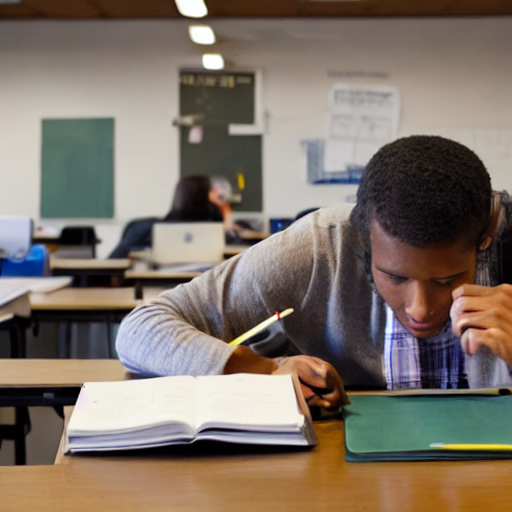

In [77]:
from PIL import Image

from PIL import Image
from IPython.display import display
display(image)

  0%|          | 0/50 [00:00<?, ?it/s]

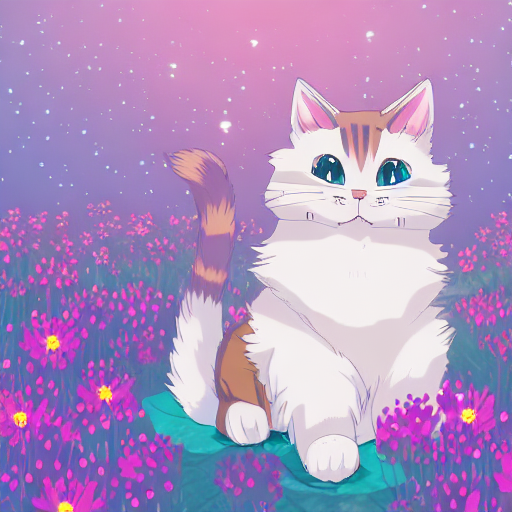

In [78]:
prompt = (
    "a cute fluffy anime-style cat with big sparkling eyes, soft pastel colors, "
    "sitting in a field of glowing flowers, highly detailed, gentle lighting, "
    "studio quality anime illustration"
)

image = pipe(prompt, guidance_scale=7.5).images[0]

image.save("generated_image.png")

image.show()

from PIL import Image

from PIL import Image
from IPython.display import display
display(image)